# Playground S6E5 - F1 Pit Stops

## Score: .94478

## EDA:

In [51]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

In [52]:
train_path = 'data/train.csv'
test_path = 'data/test.csv'
sub_path = 'data/sample_submission.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_sub = pd.read_csv(sub_path)

print('train shape:', train.shape)
print('test shape :', test.shape)
print('sample sub :', sample_sub.shape)

display(train.head())

train shape: (439140, 16)
test shape : (188165, 15)
sample sub : (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [53]:
print('Train dtypes:')
display(train.dtypes)

cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(exclude=['object']).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns ({len(num_cols)}): {num_cols}')

Train dtypes:


id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

Categorical columns (3): ['Driver', 'Compound', 'Race']
Numeric columns (13): ['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [54]:
missing_train = train.isna().sum().sort_values(ascending=False)
missing_test = test.isna().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'train_missing': missing_train,
    'train_missing_pct': (missing_train / len(train) * 100).round(2),
    'test_missing': missing_test,
    'test_missing_pct': (missing_test / len(test) * 100).round(2),
}).sort_values('train_missing', ascending=False)

display(missing_df[missing_df[['train_missing', 'test_missing']].max(axis=1) > 0])
print('No missing values detected.' if missing_df[['train_missing','test_missing']].to_numpy().max() == 0 else 'Missing values present.')

,train_missing,train_missing_pct,test_missing,test_missing_pct


Missing values present.


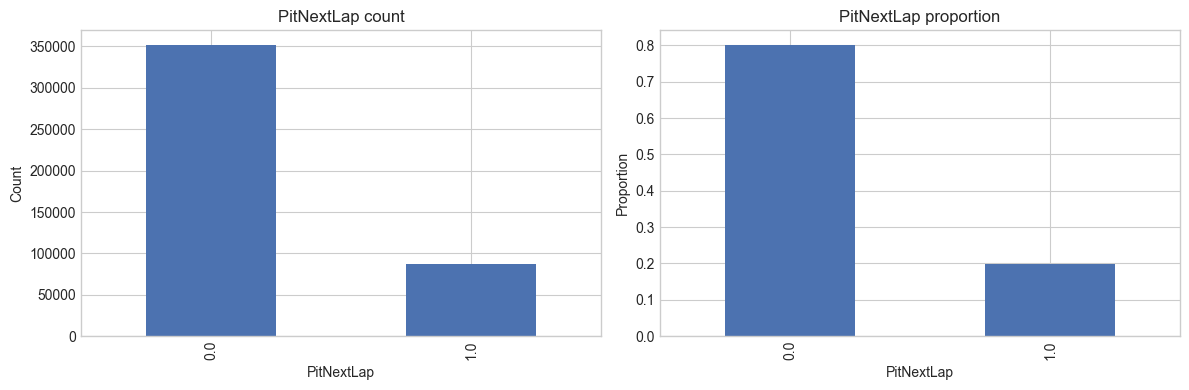

Target mean (positive rate): 0.198982


In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

value_counts = train['PitNextLap'].value_counts().sort_index()
value_counts.plot(kind='bar', ax=ax[0])
ax[0].set_title('PitNextLap count')
ax[0].set_xlabel('PitNextLap')
ax[0].set_ylabel('Count')

train['PitNextLap'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=ax[1])
ax[1].set_title('PitNextLap proportion')
ax[1].set_xlabel('PitNextLap')
ax[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

print('Target mean (positive rate):', round(train['PitNextLap'].mean(), 6))

In [56]:
for col in cat_cols:
    print(f'\n===== {col} =====')
    display(train[col].value_counts(dropna=False).head(15))


===== Driver =====


Driver
MAS    1682
RAI    1669
BAR    1656
BUT    1655
FIS    1651
KUB    1650
TRU    1613
KOV    1607
HEI    1587
SUT    1579
WEB    1576
NOR    1563
BIA    1539
NAK    1534
GUT    1529
Name: count, dtype: int64


===== Compound =====


Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64


===== Race =====


Race
Dutch Grand Prix            24462
Mexico City Grand Prix      23672
Pre-Season Testing          22492
Hungarian Grand Prix        22481
Monaco Grand Prix           21539
Canadian Grand Prix         21416
Austrian Grand Prix         21223
Spanish Grand Prix          20483
Italian Grand Prix          19854
Bahrain Grand Prix          19535
Singapore Grand Prix        18960
Miami Grand Prix            18860
Australian Grand Prix       18406
Saudi Arabian Grand Prix    18111
United States Grand Prix    18045
Name: count, dtype: int64

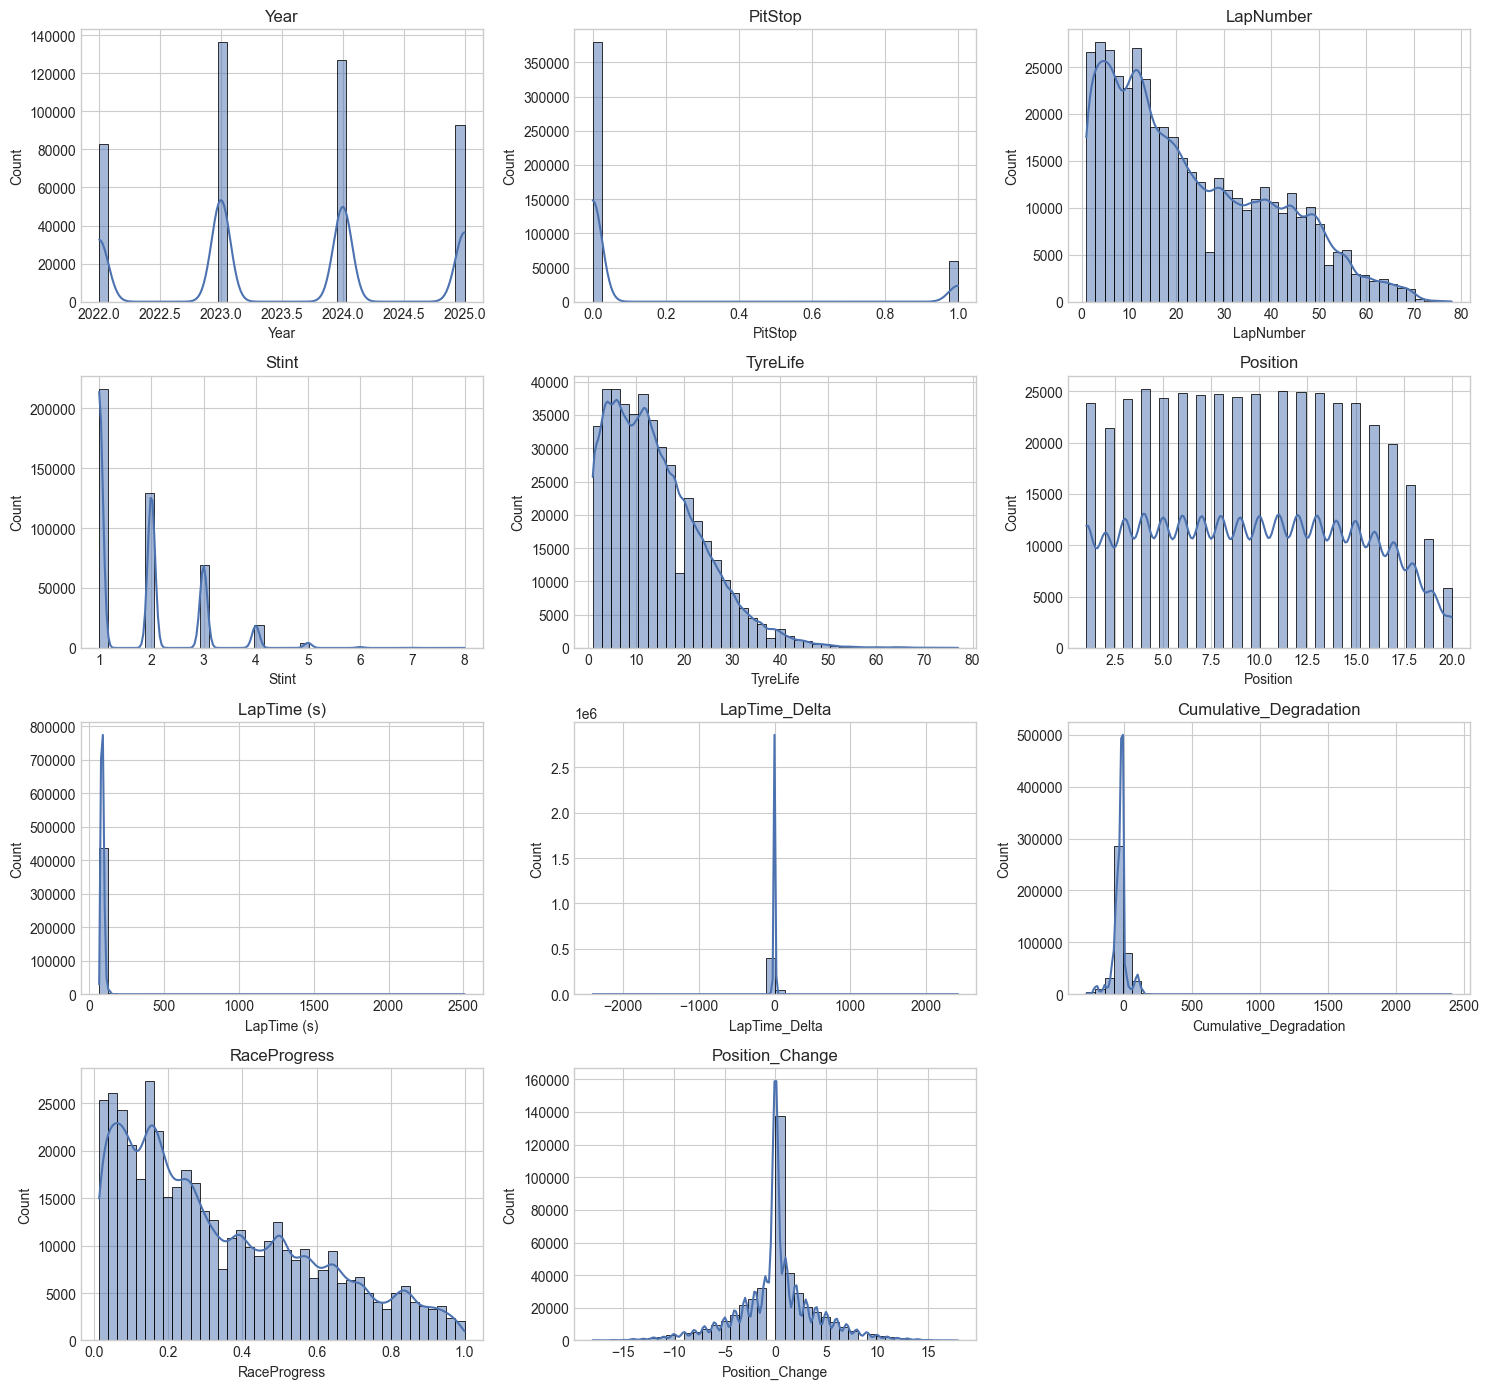

In [57]:
numeric_without_target = [c for c in num_cols if c not in ['id', 'PitNextLap']]
n_cols = 3
n_rows = int(np.ceil(len(numeric_without_target) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_without_target):
    sns.histplot(train[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

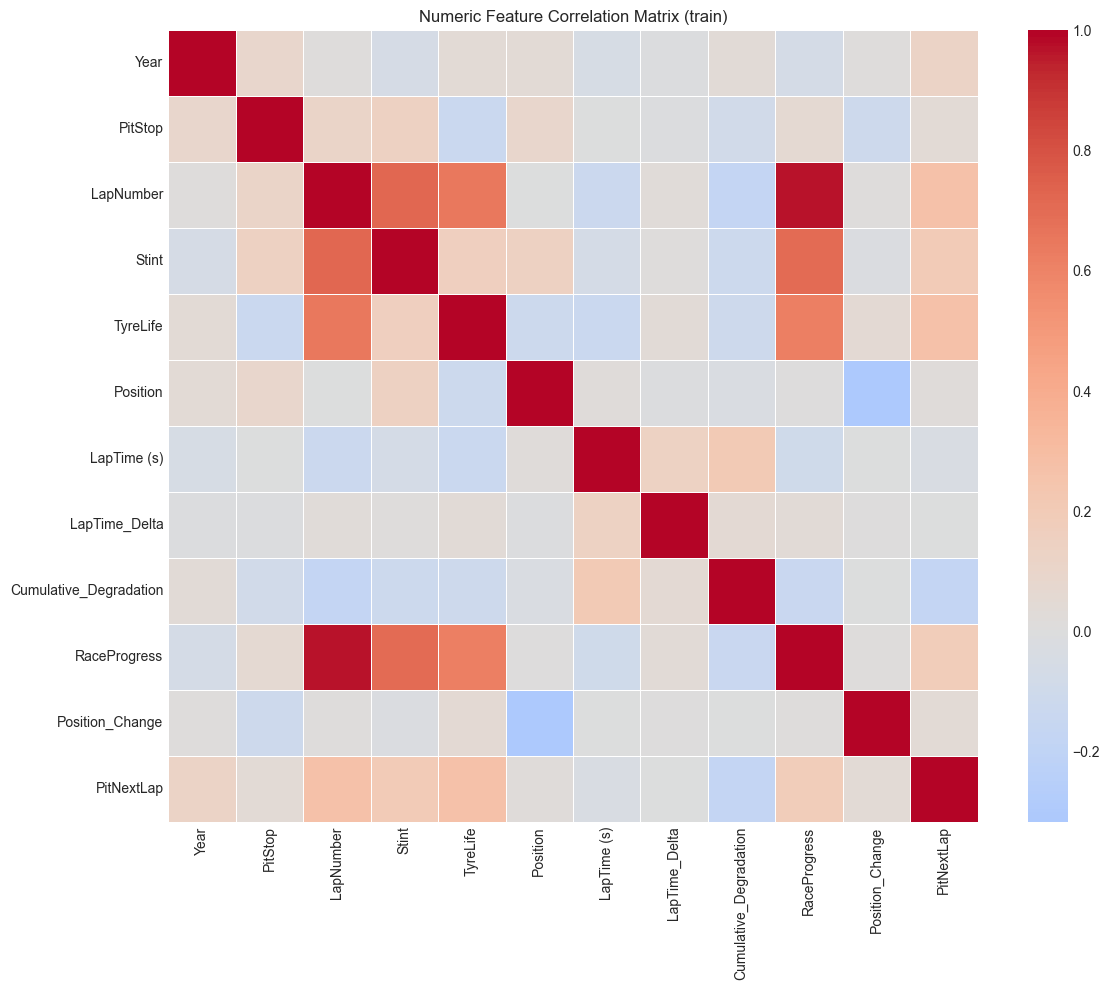

In [58]:
corr_cols = [c for c in train.columns if train[c].dtype != 'object' and c != 'id']
corr_matrix = train[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Numeric Feature Correlation Matrix (train)')
plt.tight_layout()
plt.show()

,corr_with_PitNextLap
TyreLife,0.273510
LapNumber,0.267057
Stint,0.198193
RaceProgress,0.185477
Cumulative_Degradation,-0.167401
Year,0.125267
PitStop,0.048567
Position_Change,0.046230
LapTime (s),-0.034096
Position,0.021348


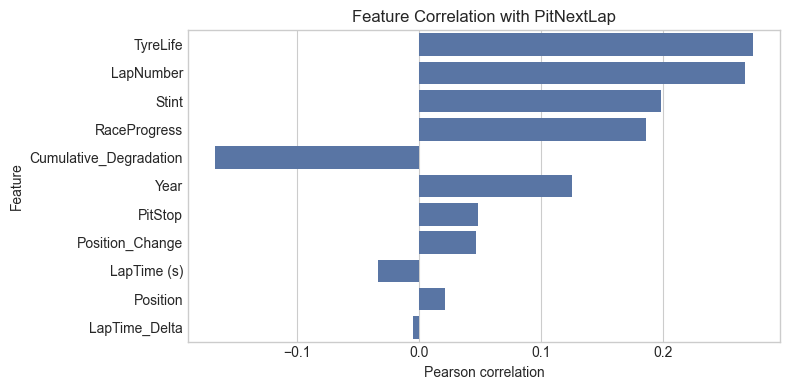

In [59]:
corr_with_target = corr_matrix['PitNextLap'].drop('PitNextLap').sort_values(key=np.abs, ascending=False)
display(corr_with_target.to_frame('corr_with_PitNextLap'))

plt.figure(figsize=(8, max(4, len(corr_with_target) * 0.35)))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, orient='h')
plt.title('Feature Correlation with PitNextLap')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [60]:
for col in cat_cols:
    tmp = train.groupby(col, dropna=False)['PitNextLap'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(f'\nTarget rate by {col}:')
    display(tmp.head(20))


Target rate by Driver:


,mean,count
Driver,,
VET,0.565460,359
MSC,0.473239,355
HAD,0.462069,435
STR,0.427451,1275
ANT,0.410072,417
LAT,0.403990,401
BEA,0.400000,555
ALO,0.393218,1386
BOR,0.387892,446



Target rate by Compound:


,mean,count
Compound,,
HARD,0.327537,170518
SOFT,0.193475,38744
INTERMEDIATE,0.152284,17382
MEDIUM,0.101131,211141
WET,0.025092,1355



Target rate by Race:


,mean,count
Race,,
Chinese Grand Prix,0.388593,7311
Monaco Grand Prix,0.357398,21539
Spanish Grand Prix,0.319973,20483
Bahrain Grand Prix,0.287535,19535
Belgian Grand Prix,0.280382,9002
Emilia Romagna Grand Prix,0.272557,15483
French Grand Prix,0.257457,3185
São Paulo Grand Prix,0.253718,11497
Hungarian Grand Prix,0.239269,22481


## Model

In [61]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

try:
    from catboost import CatBoostClassifier
    has_catboost = True
except Exception:
    has_catboost = False

print('CatBoost available:', has_catboost)

CatBoost available: True


In [62]:
target_col = 'PitNextLap'
features = [c for c in train.columns if c not in ['id', target_col]]

X = train[features].copy()
y = train[target_col].copy()
X_test = test[features].copy()

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(train))
test_pred = np.zeros(len(test))
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    if has_catboost:
        model = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            learning_rate=0.08,
            depth=6,
            iterations=300,
            random_state=42,
            verbose=100
        )
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_va, y_va), use_best_model=True)
        va_pred = model.predict_proba(X_va)[:, 1]
        te_pred = model.predict_proba(X_test)[:, 1]
    else:
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_features),
                ('cat', Pipeline([
                    ('imp', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]), cat_features)
            ],
            remainder='drop'
        )

        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
        ])
        model.fit(X_tr, y_tr)
        va_pred = model.predict_proba(X_va)[:, 1]
        te_pred = model.predict_proba(X_test)[:, 1]

    oof[va_idx] = va_pred
    test_pred += te_pred / skf.n_splits
    fold_auc = roc_auc_score(y_va, va_pred)
    fold_scores.append(fold_auc)
    print(f'Fold {fold} AUC: {fold_auc:.6f}')

cv_auc = roc_auc_score(y, oof)
print('\nFold AUCs:', [round(s, 6) for s in fold_scores])
print(f'CV AUC: {cv_auc:.6f}')

0:	test: 0.9000920	best: 0.9000920 (0)	total: 150ms	remaining: 44.7s
100:	test: 0.9341108	best: 0.9341108 (100)	total: 16.6s	remaining: 32.7s
200:	test: 0.9401023	best: 0.9401023 (200)	total: 31.9s	remaining: 15.7s
299:	test: 0.9424981	best: 0.9424981 (299)	total: 47.5s	remaining: 0us

bestTest = 0.9424981327
bestIteration = 299

Fold 1 AUC: 0.942498
0:	test: 0.8974261	best: 0.8974261 (0)	total: 194ms	remaining: 58.1s
100:	test: 0.9326237	best: 0.9326237 (100)	total: 15.9s	remaining: 31.3s
200:	test: 0.9382833	best: 0.9382833 (200)	total: 31.7s	remaining: 15.6s
299:	test: 0.9409466	best: 0.9409466 (299)	total: 47.6s	remaining: 0us

bestTest = 0.9409466015
bestIteration = 299

Fold 2 AUC: 0.940947
0:	test: 0.8991363	best: 0.8991363 (0)	total: 173ms	remaining: 51.8s
100:	test: 0.9334626	best: 0.9334626 (100)	total: 16.7s	remaining: 32.9s
200:	test: 0.9395951	best: 0.9395951 (200)	total: 32.2s	remaining: 15.8s
299:	test: 0.9423150	best: 0.9423150 (299)	total: 47.5s	remaining: 0us

bestTes

In [63]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_pred
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
display(submission.head())

Saved submission.csv


,id,PitNextLap
0,439140,0.005405
1,439141,0.007841
2,439142,0.006167
3,439143,0.094902
4,439144,0.739179


## Model conservative v2

In [64]:
target_col = 'PitNextLap'
features = [c for c in train.columns if c not in ['id', target_col]]

X = train[features].copy()
y = train[target_col].copy()
X_test = test[features].copy()

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_safe = np.zeros(len(train))
test_pred_safe = np.zeros(len(test))
fold_scores_safe = []

if has_catboost:
    seeds = [42, 99]
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        va_fold = np.zeros(len(va_idx))
        te_fold = np.zeros(len(test))

        for seed in seeds:
            model = CatBoostClassifier(
                loss_function='Logloss',
                eval_metric='AUC',
                learning_rate=0.06,
                depth=6,
                iterations=500,
                l2_leaf_reg=5,
                random_state=seed,
                verbose=False
            )
            model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_va, y_va), use_best_model=True)
            va_fold += model.predict_proba(X_va)[:, 1] / len(seeds)
            te_fold += model.predict_proba(X_test)[:, 1] / len(seeds)

        oof_safe[va_idx] = va_fold
        test_pred_safe += te_fold / skf.n_splits
        fold_auc = roc_auc_score(y_va, va_fold)
        fold_scores_safe.append(fold_auc)
        print(f'Fold {fold} AUC: {fold_auc:.6f}')
else:
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_features),
                ('cat', Pipeline([
                    ('imp', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]), cat_features)
            ],
            remainder='drop'
        )

        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
        ])
        model.fit(X_tr, y_tr)
        va_pred = model.predict_proba(X_va)[:, 1]
        te_pred = model.predict_proba(X_test)[:, 1]

        oof_safe[va_idx] = va_pred
        test_pred_safe += te_pred / skf.n_splits
        fold_auc = roc_auc_score(y_va, va_pred)
        fold_scores_safe.append(fold_auc)
        print(f'Fold {fold} AUC: {fold_auc:.6f}')

cv_auc_safe = roc_auc_score(y, oof_safe)
print('\nFold AUCs:', [round(s, 6) for s in fold_scores_safe])
print(f'CV AUC: {cv_auc_safe:.6f}')

Fold 1 AUC: 0.944363
Fold 2 AUC: 0.942149
Fold 3 AUC: 0.943657
Fold 4 AUC: 0.942520
Fold 5 AUC: 0.943184

Fold AUCs: [0.944363, 0.942149, 0.943657, 0.94252, 0.943184]
CV AUC: 0.943169


In [65]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_pred_safe
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
display(submission.head())

Saved submission.csv


,id,PitNextLap
0,439140,0.005402
1,439141,0.006414
2,439142,0.006169
3,439143,0.093383
4,439144,0.764210


## Model conservative v3

In [66]:
target_col = 'PitNextLap'
features = [c for c in train.columns if c not in ['id', target_col]]

X = train[features].copy()
y = train[target_col].copy()
X_test = test[features].copy()

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_v3 = np.zeros(len(train))
test_pred_v3 = np.zeros(len(test))
fold_scores_v3 = []

if has_catboost:
    param_list = [
        {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'learning_rate': 0.05,
            'depth': 6,
            'iterations': 700,
            'l2_leaf_reg': 5,
            'random_strength': 1.0,
            'subsample': 0.9,
            'bootstrap_type': 'Bernoulli',
            'random_state': 42,
            'verbose': False
        },
        {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'learning_rate': 0.04,
            'depth': 7,
            'iterations': 900,
            'l2_leaf_reg': 7,
            'random_strength': 1.2,
            'subsample': 0.85,
            'bootstrap_type': 'Bernoulli',
            'random_state': 99,
            'verbose': False
        },
        {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'learning_rate': 0.06,
            'depth': 5,
            'iterations': 800,
            'l2_leaf_reg': 4,
            'random_strength': 0.8,
            'subsample': 0.95,
            'bootstrap_type': 'Bernoulli',
            'random_state': 7,
            'verbose': False
        }
    ]

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        va_fold = np.zeros(len(va_idx))
        te_fold = np.zeros(len(test))

        for params in param_list:
            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_va, y_va), use_best_model=True)
            va_fold += model.predict_proba(X_va)[:, 1] / len(param_list)
            te_fold += model.predict_proba(X_test)[:, 1] / len(param_list)

        oof_v3[va_idx] = va_fold
        test_pred_v3 += te_fold / skf.n_splits
        fold_auc = roc_auc_score(y_va, va_fold)
        fold_scores_v3.append(fold_auc)
        print(f'Fold {fold} AUC: {fold_auc:.6f}')
else:
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_features),
                ('cat', Pipeline([
                    ('imp', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]), cat_features)
            ],
            remainder='drop'
        )

        model = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
        ])
        model.fit(X_tr, y_tr)
        va_pred = model.predict_proba(X_va)[:, 1]
        te_pred = model.predict_proba(X_test)[:, 1]

        oof_v3[va_idx] = va_pred
        test_pred_v3 += te_pred / skf.n_splits
        fold_auc = roc_auc_score(y_va, va_pred)
        fold_scores_v3.append(fold_auc)
        print(f'Fold {fold} AUC: {fold_auc:.6f}')

cv_auc_v3 = roc_auc_score(y, oof_v3)
print('\nFold AUCs:', [round(s, 6) for s in fold_scores_v3])
print(f'CV AUC: {cv_auc_v3:.6f}')

Fold 1 AUC: 0.945466
Fold 2 AUC: 0.943455
Fold 3 AUC: 0.944956
Fold 4 AUC: 0.943743
Fold 5 AUC: 0.944376

Fold AUCs: [0.945466, 0.943455, 0.944956, 0.943743, 0.944376]
CV AUC: 0.944396


In [67]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_pred_v3
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
display(submission.head())

Saved submission.csv


,id,PitNextLap
0,439140,0.005186
1,439141,0.005724
2,439142,0.005903
3,439143,0.090782
4,439144,0.775487


## Model conservative v5 oof blend

In [68]:
from sklearn.preprocessing import OrdinalEncoder

target_col = 'PitNextLap'
features = [c for c in train.columns if c not in ['id', target_col]]
X = train[features].copy()
y = train[target_col].copy()
X_test = test[features].copy()
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

param_list = [
    {'loss_function': 'Logloss', 'eval_metric': 'AUC', 'learning_rate': 0.05, 'depth': 6, 'iterations': 700, 'l2_leaf_reg': 5, 'random_strength': 1.0, 'subsample': 0.9, 'bootstrap_type': 'Bernoulli', 'random_state': 42, 'verbose': False},
    {'loss_function': 'Logloss', 'eval_metric': 'AUC', 'learning_rate': 0.04, 'depth': 7, 'iterations': 900, 'l2_leaf_reg': 7, 'random_strength': 1.2, 'subsample': 0.85, 'bootstrap_type': 'Bernoulli', 'random_state': 99, 'verbose': False},
    {'loss_function': 'Logloss', 'eval_metric': 'AUC', 'learning_rate': 0.06, 'depth': 5, 'iterations': 800, 'l2_leaf_reg': 4, 'random_strength': 0.8, 'subsample': 0.95, 'bootstrap_type': 'Bernoulli', 'random_state': 7, 'verbose': False},
]

try:
    import lightgbm as lgb
    has_lgb = True
except Exception:
    has_lgb = False

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_cb = np.zeros(len(train))
oof_aux = np.zeros(len(train))
test_cb = np.zeros(len(test))
test_aux = np.zeros(len(test))

if has_catboost:
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        va_cb = np.zeros(len(va_idx))
        te_cb = np.zeros(len(test))
        for params in param_list:
            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_va, y_va), use_best_model=True)
            va_cb += model.predict_proba(X_va)[:, 1] / len(param_list)
            te_cb += model.predict_proba(X_test)[:, 1] / len(param_list)
        oof_cb[va_idx] = va_cb
        test_cb += te_cb / skf.n_splits

        if has_lgb:
            X_tr_l = X_tr.copy()
            X_va_l = X_va.copy()
            X_te_l = X_test.copy()
            oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            oe.fit(X_tr_l[cat_features])
            X_tr_l[cat_features] = oe.transform(X_tr_l[cat_features])
            X_va_l[cat_features] = oe.transform(X_va_l[cat_features])
            X_te_l[cat_features] = oe.transform(X_te_l[cat_features])
            cat_idx = [X_tr_l.columns.get_loc(c) for c in cat_features]
            dtrain = lgb.Dataset(X_tr_l, label=y_tr, categorical_feature=cat_idx)
            dval = lgb.Dataset(X_va_l, label=y_va, categorical_feature=cat_idx, reference=dtrain)
            params_lgb = {
                'objective': 'binary',
                'metric': 'auc',
                'verbosity': -1,
                'learning_rate': 0.045,
                'num_leaves': 64,
                'feature_fraction': 0.85,
                'bagging_fraction': 0.85,
                'bagging_freq': 1,
                'min_data_in_leaf': 140,
                'random_state': 42 + fold,
            }
            bst = lgb.train(
                params_lgb,
                dtrain,
                num_boost_round=1200,
                valid_sets=[dval],
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            bi = getattr(bst, 'best_iteration', None)
            best_it = bi if bi is not None and bi > 0 else bst.num_trees()
            va_l = bst.predict(X_va_l, num_iteration=best_it)
            te_l = bst.predict(X_te_l, num_iteration=best_it)
            oof_aux[va_idx] = va_l
            test_aux += te_l / skf.n_splits
        else:
            model_aux = CatBoostClassifier(
                loss_function='Logloss',
                eval_metric='AUC',
                learning_rate=0.07,
                depth=8,
                iterations=450,
                l2_leaf_reg=9,
                random_state=123 + fold,
                verbose=False,
            )
            model_aux.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_va, y_va), use_best_model=True)
            oof_aux[va_idx] = model_aux.predict_proba(X_va)[:, 1]
            test_aux += model_aux.predict_proba(X_test)[:, 1] / skf.n_splits

        auc_cb = roc_auc_score(y_va, oof_cb[va_idx])
        auc_aux = roc_auc_score(y_va, oof_aux[va_idx])
        print(f'Fold {fold} CatBoostEns AUC {auc_cb:.6f} Aux AUC {auc_aux:.6f}')

    best_w = 1.0
    best_auc = roc_auc_score(y, oof_cb)
    for w in np.linspace(0.0, 1.0, 101):
        blend_oof = w * oof_cb + (1.0 - w) * oof_aux
        auc = roc_auc_score(y, blend_oof)
        if auc > best_auc:
            best_auc = auc
            best_w = w
    lo = max(0.0, best_w - 0.06)
    hi = min(1.0, best_w + 0.06)
    for w in np.linspace(lo, hi, 49):
        blend_oof = w * oof_cb + (1.0 - w) * oof_aux
        auc = roc_auc_score(y, blend_oof)
        if auc > best_auc:
            best_auc = auc
            best_w = w
    blend_oof = best_w * oof_cb + (1.0 - best_w) * oof_aux
    blend_te = best_w * test_cb + (1.0 - best_w) * test_aux
    eps = 1e-6
    bo = np.clip(blend_oof, eps, 1.0 - eps)
    zo = np.log(bo / (1.0 - bo))
    best_T = 1.0
    for T in np.linspace(0.88, 1.12, 25):
        pr = 1.0 / (1.0 + np.exp(-zo / T))
        auc = roc_auc_score(y, pr)
        if auc > best_auc:
            best_auc = auc
            best_T = T
    bt = np.clip(blend_te, eps, 1.0 - eps)
    zte = np.log(bt / (1.0 - bt))
    test_final = 1.0 / (1.0 + np.exp(-zte / best_T))
    print(f'OOF blend w_catboost={best_w:.4f} w_aux={1.0 - best_w:.4f} CV AUC {best_auc:.6f} T={best_T:.4f}')
else:
    oof_lr = np.zeros(len(train))
    test_lr = np.zeros(len(test))
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_features),
                ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
            ],
            remainder='drop',
        )
        model = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])
        model.fit(X_tr, y_tr)
        oof_lr[va_idx] = model.predict_proba(X_va)[:, 1]
        test_lr += model.predict_proba(X_test)[:, 1] / skf.n_splits
    test_final = test_lr
    print('CV AUC LR only:', roc_auc_score(y, oof_lr))

submission = pd.DataFrame({'id': test['id'], 'PitNextLap': test_final})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
display(submission.head())

Fold 1 CatBoostEns AUC 0.945466 Aux AUC 0.944053
Fold 2 CatBoostEns AUC 0.943455 Aux AUC 0.942545
Fold 3 CatBoostEns AUC 0.944956 Aux AUC 0.942395
Fold 4 CatBoostEns AUC 0.943743 Aux AUC 0.942135
Fold 5 CatBoostEns AUC 0.944376 Aux AUC 0.943287
OOF blend w_catboost=0.6275 w_aux=0.3725 CV AUC 0.945536 T=1.0000
Saved submission.csv


,id,PitNextLap
0,439140,0.004977
1,439141,0.004175
2,439142,0.006267
3,439143,0.109612
4,439144,0.813389
